# Chapter 22 — MQTT Protocol: Hands-On Python Practice
## *Fundamentals of the Internet of Things*
**Oleksandr Kuznetsov** · eCampus University, Novedrate (CO), Italy

---

> **How to use this notebook.** Each exercise is self-contained: read the
> background, run the code cells in order, study the output, then read the
> analysis. A fixed pseudorandom seed is set once in Setup so that every
> reader obtains numerically consistent Monte Carlo results; the timing
> figures in Exercise 22.3 depend on the reader's own hardware — the
> qualitative scaling trend reproduces across machines, but absolute
> timings, and even the exact speed-up ratio, do not.
>
> **Exercises in this notebook**
> 1. **22.1 — MQTT Packet Overhead and Fleet-Scale Bandwidth Cost.** A
>    byte-exact MQTT v3.1.1 PUBLISH packet-size calculator, used to estimate protocol
>    overhead and monthly data volume for a device fleet, with and without
>    TLS 1.2.
> 2. **22.2 — QoS Delivery Reliability under Connection Loss.** A
>    simulation of the QoS 1/2 acknowledgement state machines under
>    connection loss and session-resumption, with a *shared* retry budget
>    across QoS 2's two stages for a controlled, like-for-like comparison
>    with QoS 1, validated
>    against closed-form probabilities.
> 3. **22.3 — Subscription-Matching Scalability.** A from-scratch topic
>    trie benchmarked against naive linear subscription scanning, on a
>    synthetic smart-building topic hierarchy.
> 4. **22.4 — Session Persistence, Keep Alive, and the Will Message.**
>    Failure-detection latency, keep-alive traffic cost, and offline
>    message-queue overflow risk for persistent sessions, with a
>    closed-form reliability check.

---
## Setup

In [1]:
# -- Setup -------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import random
import time
import pickle

np.random.seed(42)
random.seed(42)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

# ---- MQTT v3.1.1 wire-format helpers (OASIS MQTT v3.1.1, Sec. 2.2.3, 3.3) --
def remaining_length_field_bytes(n):
    '''Number of bytes the variable-byte-integer Remaining Length field
    occupies for value n -- a byte COUNT, not an encoded byte sequence.
    This notebook is a byte-exact size CALCULATOR, not a full packet
    serialiser: it does not emit an actual wire-format byte string,
    validate topic well-formedness, or check the QoS range.'''
    if not 0 <= n <= 268_435_455:
        raise ValueError('Remaining Length is outside the MQTT range (0 to 256 MB - 1)')
    count, x = 0, n
    while True:
        x //= 128
        count += 1
        if x == 0:
            return count

def publish_packet_bytes(topic, payload_bytes, qos):
    '''Exact MQTT v3.1.1 PUBLISH packet size in bytes (MQTT layer only --
    this is the Fixed Header + Variable Header + Payload; it does NOT
    include any TCP/IP or TLS overhead, which is added separately below).'''
    variable_header = 2 + len(topic.encode('utf-8'))
    if qos > 0:
        variable_header += 2                          # Packet Identifier
    remaining_length = variable_header + payload_bytes
    return 1 + remaining_length_field_bytes(remaining_length) + remaining_length

def ack_packet_bytes(kind):
    '''PUBACK / PUBREC / PUBREL / PUBCOMP are all 4 bytes (MQTT layer).'''
    return {'PUBACK': 4, 'PUBREC': 4, 'PUBREL': 4, 'PUBCOMP': 4}[kind]

_checks = {0: 1, 127: 1, 128: 2, 16383: 2, 16384: 3, 2097151: 3, 2097152: 4, 268435455: 4}
for n, expected in _checks.items():
    assert remaining_length_field_bytes(n) == expected
assert publish_packet_bytes('a/b', 0, 0) == 7
print('MQTT packet-size helpers verified against OASIS MQTT v3.1.1 Section 2.2.3.')

TCP_IP_TYPICAL = 52   # bytes; typical IPv4+TCP overhead incl. common options (Mattsson, 2014)
TCP_IP_MIN     = 40   # bytes; textbook minimum, IPv4(20)+TCP(20), no options (RFC 791 / RFC 793)
# TLS 1.2 AES-GCM record overhead: 5 B record header (RFC 5246) + 8 B explicit
# nonce + 16 B authentication tag (RFC 5288); Mattsson (2014) corroborates the
# resulting 29 B total. This is TLS 1.2 with AES-GCM specifically -- TLS 1.3's
# record construction differs and is not modelled here.
TLS12_AES_GCM  = 29   # bytes

MQTT packet-size helpers verified against OASIS MQTT v3.1.1 Section 2.2.3.


---
## Exercise 22.1 — MQTT Packet Overhead and Fleet-Scale Bandwidth Cost

### Background

MQTT is routinely described as "lightweight," but that claim is rarely
backed by an actual byte count. This exercise builds an exact,
byte-level **packet-size calculator** for the MQTT v3.1.1 PUBLISH packet,
computed directly from the wire format defined in the OASIS specification
(it computes sizes, not an actual serialised byte string, and does not
validate topic well-formedness, QoS range, or Remaining Length range --
those checks live in the helper functions' assertions, not in a full
packet encoder), and uses it to answer three concrete questions: how
much of a PUBLISH packet is payload versus protocol overhead; how much
extra traffic the QoS 1/2 acknowledgement handshakes add; and what this
means for a device fleet over a month, with and without TLS 1.2.

All bandwidth figures below are a **steady-state IP-layer traffic estimate
under the assumption of one MQTT Control Packet per TCP segment (and, if
TLS is used, one TLS record per segment)**. This is a simplifying
assumption, not a strict upper or lower bound: separate TCP ACK-only
segments, TCP retransmissions, connection establishment (the TCP and TLS
handshakes), and link-layer (Ethernet/Wi-Fi/cellular) overhead are all
*omitted* here and would each push the real figure higher, while OS-level
coalescing of several small writes into one segment (Nagle's algorithm,
delayed ACKs) would push it lower. Challenge Task 2 explores what changes
under a batching assumption.

In [2]:
# -- Exercise 22.1: packet-size sweep -----------------------------------
TOPIC = "building/12/floor/3/room/301/sensor/temperature"
print(f"Representative topic: '{TOPIC}'  ({len(TOPIC.encode('utf-8'))} bytes UTF-8)")

payload_sizes = np.arange(1, 201)
qos_levels = [0, 1, 2]
mqtt_bytes, overhead_ratio = {}, {}
for qos in qos_levels:
    sizes = np.array([publish_packet_bytes(TOPIC, p, qos) for p in payload_sizes])
    mqtt_bytes[qos] = sizes
    overhead_ratio[qos] = (sizes - payload_sizes) / sizes * 100.0

# 24 bytes is a round, representative figure for a small structured telemetry
# reading -- e.g. a compact JSON object such as {"t":23.5,"h":41.2} (19 bytes)
# padded with a couple more fields, or an equivalent binary encoding. It is
# not tied to one exact string; the analysis below only uses the byte count.
PAYLOAD_REF = 24
publish_size = {qos: publish_packet_bytes(TOPIC, PAYLOAD_REF, qos) for qos in qos_levels}
handshake_size = {0: 0,
                   1: ack_packet_bytes('PUBACK'),
                   2: ack_packet_bytes('PUBREC') + ack_packet_bytes('PUBREL') + ack_packet_bytes('PUBCOMP')}

print(f"\nPUBLISH packet, {PAYLOAD_REF}-byte payload:")
for qos in qos_levels:
    print(f"  QoS{qos}: PUBLISH={publish_size[qos]:3d} B   handshake={handshake_size[qos]:2d} B   "
          f"MQTT-layer total={publish_size[qos]+handshake_size[qos]:3d} B")

Representative topic: 'building/12/floor/3/room/301/sensor/temperature'  (47 bytes UTF-8)

PUBLISH packet, 24-byte payload:
  QoS0: PUBLISH= 75 B   handshake= 0 B   MQTT-layer total= 75 B
  QoS1: PUBLISH= 77 B   handshake= 4 B   MQTT-layer total= 81 B
  QoS2: PUBLISH= 77 B   handshake=12 B   MQTT-layer total= 89 B


In [3]:
# -- Exercise 22.1: fleet-scale monthly data volume ----------------------
N_DEVICES, PUBLISH_INTERVAL_S, DAYS = 1000, 60, 30
msgs_per_device = (86400 // PUBLISH_INTERVAL_S) * DAYS
print(f"Messages/device over {DAYS} days at 1 msg/{PUBLISH_INTERVAL_S}s: {msgs_per_device}")

def n_segments_for_qos(qos):
    '''One TCP segment per Control Packet: PUBLISH, plus one per ack.'''
    return 1 + (1 if qos == 1 else (3 if qos == 2 else 0))

def monthly_MB(qos, tls, tcp_overhead=TCP_IP_TYPICAL):
    mqtt_total = publish_size[qos] + handshake_size[qos]
    n_seg = n_segments_for_qos(qos)
    wire_total = mqtt_total + n_seg * tcp_overhead
    if tls:
        wire_total += n_seg * TLS12_AES_GCM
    return wire_total * msgs_per_device * N_DEVICES / 1e6  # MB

results_c = {(qos, tls): monthly_MB(qos, tls) for qos in qos_levels for tls in (False, True)}
print(f"\nMonthly fleet data volume (N={N_DEVICES} devices, 1 msg/min, {DAYS} days):")
for qos in qos_levels:
    no_tls, with_tls = results_c[(qos, False)], results_c[(qos, True)]
    mqtt_total = publish_size[qos] + handshake_size[qos]
    wire_no_tls = mqtt_total + n_segments_for_qos(qos) * TCP_IP_TYPICAL
    print(f"  QoS{qos}: wire/MQTT-layer ratio (no TLS) = {wire_no_tls/mqtt_total:.2f}x   "
          f"no TLS = {no_tls:8.1f} MB   with TLS 1.2 = {with_tls:8.1f} MB  (+{100*(with_tls/no_tls-1):.1f}%)")
print(f"\nQoS0 -> QoS2 monthly-volume ratio: no TLS = {results_c[(2,False)]/results_c[(0,False)]:.2f}x, "
      f"with TLS = {results_c[(2,True)]/results_c[(0,True)]:.2f}x")

Messages/device over 30 days at 1 msg/60s: 43200

Monthly fleet data volume (N=1000 devices, 1 msg/min, 30 days):
  QoS0: wire/MQTT-layer ratio (no TLS) = 1.69x   no TLS =   5486.4 MB   with TLS 1.2 =   6739.2 MB  (+22.8%)
  QoS1: wire/MQTT-layer ratio (no TLS) = 2.28x   no TLS =   7992.0 MB   with TLS 1.2 =  10497.6 MB  (+31.4%)
  QoS2: wire/MQTT-layer ratio (no TLS) = 3.34x   no TLS =  12830.4 MB   with TLS 1.2 =  17841.6 MB  (+39.1%)

QoS0 -> QoS2 monthly-volume ratio: no TLS = 2.34x, with TLS = 2.65x


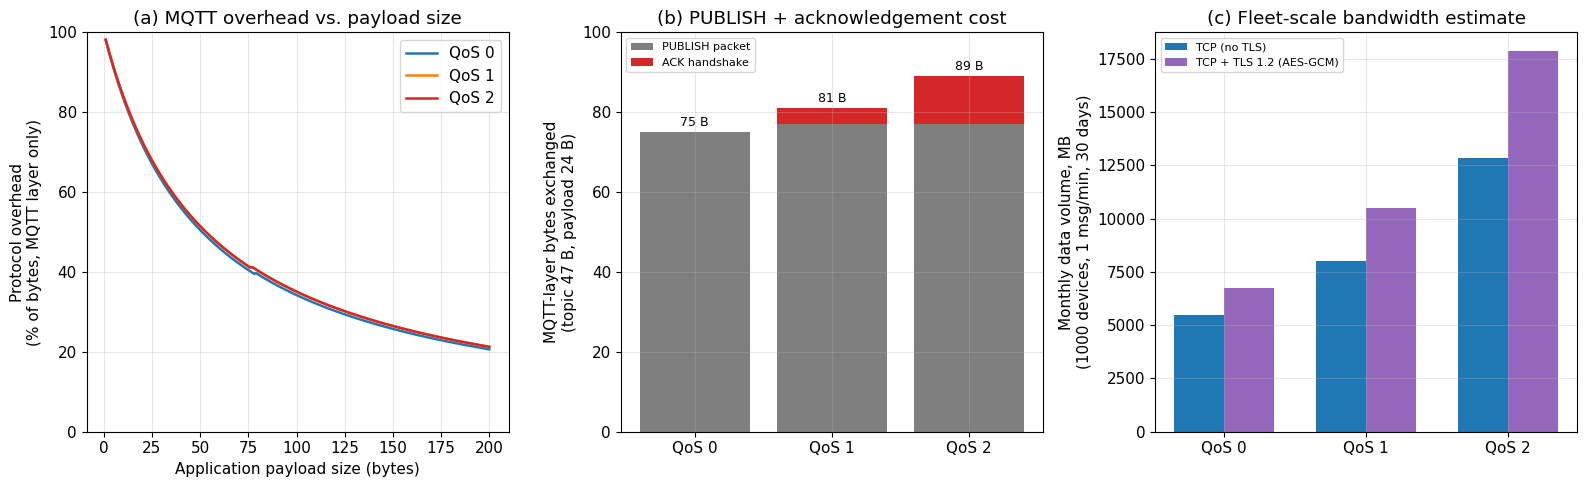

In [4]:
# -- Figure 22.1: overhead ratio, byte breakdown, fleet data volume -----
colors = {0: 'tab:blue', 1: 'tab:orange', 2: 'tab:red'}
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
for qos in qos_levels:
    ax.plot(payload_sizes, overhead_ratio[qos], color=colors[qos], lw=1.8, label=f'QoS {qos}')
ax.set_xlabel('Application payload size (bytes)')
ax.set_ylabel('Protocol overhead\n(% of bytes, MQTT layer only)')
ax.set_title('(a) MQTT overhead vs. payload size')
ax.legend(); ax.set_ylim(0, 100)

ax = axes[1]
qos_labels = ['QoS 0', 'QoS 1', 'QoS 2']
x = np.arange(3)
pb = [publish_size[q] for q in qos_levels]; hb = [handshake_size[q] for q in qos_levels]
ax.bar(x, pb, color='tab:gray', label='PUBLISH packet')
ax.bar(x, hb, bottom=pb, color='tab:red', label='ACK handshake')
for i in range(3):
    ax.text(i, pb[i] + hb[i] + 1.5, f'{pb[i]+hb[i]} B', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(qos_labels)
ax.set_ylabel(f'MQTT-layer bytes exchanged\n(topic {len(TOPIC)} B, payload {PAYLOAD_REF} B)')
ax.set_title('(b) PUBLISH + acknowledgement cost')
ax.legend(fontsize=8); ax.set_ylim(0, 100)

ax = axes[2]
width = 0.35
no_tls = [results_c[(q, False)] for q in qos_levels]; with_tls = [results_c[(q, True)] for q in qos_levels]
ax.bar(x - width/2, no_tls, width, color='tab:blue', label='TCP (no TLS)')
ax.bar(x + width/2, with_tls, width, color='tab:purple', label='TCP + TLS 1.2 (AES-GCM)')
ax.set_xticks(x); ax.set_xticklabels(qos_labels)
ax.set_ylabel(f'Monthly data volume, MB\n({N_DEVICES} devices, 1 msg/min, {DAYS} days)')
ax.set_title('(c) Fleet-scale bandwidth estimate')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_22_1_packet_overhead.png', dpi=150, bbox_inches='tight')
plt.show()

### Analysis

**Figure 22.1(a)** shows that at very small payloads (a single-byte flag or
alarm bit) MQTT overhead exceeds 98% of the bytes, but it falls off
quickly: by the 24-byte reference payload it is down to roughly two-thirds
of the packet, by 100 bytes it is around a third, and by 200 bytes it
approaches one-fifth. The three QoS curves stay close together throughout,
because the only structural difference between them is the 2-byte Packet
Identifier — small next to a 47-byte topic name. This is the single
biggest lever a designer actually controls: topic *length* matters far
more than QoS level for per-packet overhead, which argues for short,
purposeful topic hierarchies rather than verbose, self-documenting ones.

**Figure 22.1(b)** and the printed byte counts make the *acknowledgement*
cost, not the PUBLISH packet itself, the more interesting number. Going
from QoS 0 to QoS 1 adds one 4-byte PUBACK; going to QoS 2 adds three
4-byte packets (PUBREC, PUBREL, PUBCOMP) for 12 bytes of pure handshake, on
top of a PUBLISH packet that is otherwise almost identical in size. On an
MQTT-layer byte count alone this looks negligible, but **Figure 22.1(c)**
shows why it is not: under the one-packet-per-segment estimate stated
above, each acknowledgement packet adds its own TCP/IP (and, if TLS is
used, TLS record) overhead. The transport/MQTT-layer ratio is **1.7x for
QoS 0, 2.3x for QoS 1, and 3.3x for QoS 2** — the extra segments for QoS 2's
three-packet handshake cost more in transport overhead than its 12 extra
MQTT-layer bytes alone would suggest. For 1000 devices publishing once a
minute for a month, moving from QoS 0 to QoS 2 multiplies the monthly data
volume by roughly 2.3x (no TLS) to 2.7x (with TLS 1.2) — a substantial
increase, though short of tripling — and enabling TLS 1.2 adds a further
23–39% on top of either QoS level, with the *relative* TLS penalty growing
at higher QoS precisely because there are more encrypted records per
logical message. This message-acknowledgement overhead should not be
confused with TCP/TLS *connection*-establishment cost, which is a one-time
cost per connection and is not modelled here.

None of this means QoS 2 or TLS should be avoided — Exercise 22.2
quantifies what QoS 2 buys in return — but it does mean the choice has a
directly measurable, QoS-dependent cost on metered or energy-constrained
links, a cost that a bare MQTT-layer byte count alone would understate.

> **Key takeaway.** Topic-name length, not QoS level, is the dominant
> factor in per-packet MQTT overhead once payloads exceed a few dozen
> bytes. QoS level instead mostly changes the number of *transport-layer
> segments* per logical message under our one-packet-per-segment estimate —
> which is why its bandwidth cost only becomes visible once TCP/IP (and,
> if used, TLS) overhead is included, not at the MQTT layer alone, and why
> the transport/MQTT-layer ratio itself grows with QoS (1.7x/2.3x/3.3x).

**Challenge tasks.**
1. Repeat Figure 22.1(a) for MQTT v5.0, adding a representative Properties
   block (e.g., a 4-byte Message Expiry Interval plus a User Property) to
   the variable header. At what payload size does the overhead curve for
   v5.0 QoS 0 cross the v3.1.1 QoS 2 curve computed here?
2. The one-packet-per-segment estimate omits client-side batching. Suppose
   instead a client publishes 5 sensor readings in quick succession and the
   OS coalesces consecutive *outbound* PUBLISH packets from the same client
   into as few TCP segments as the maximum segment size (MSS, typically
   ~1460 bytes) allows, and, if TLS is used, into a single TLS record.
   Recompute the effective per-message overhead for QoS 0 bursts of size 1,
   5, and 20. (Acknowledgements travel in the opposite direction and cannot
   be coalesced with the PUBLISH packets that trigger them.) How much of
   the overhead in Figure 22.1(a) is amortised away by this kind of
   client-side batching?
3. Sweep the topic length from 10 to 100 characters (instead of fixing it
   at 47) and re-plot Figure 22.1(a) as a 2D heat map of overhead ratio
   over (topic length, payload size). At what combination does overhead
   drop below 10%?

---
## Exercise 22.2 — QoS Delivery Reliability under Connection Loss

### Background

MQTT assumes a transport that delivers bytes in order and without loss —
in practice, TCP, TLS over TCP, or WebSocket over TCP. While a connection
is up, the transport does not silently drop an individual PUBLISH or
PUBACK packet; TCP's own retransmission handles that invisibly to MQTT.
The failure mode MQTT's QoS machinery is actually designed around is
different: the **connection itself** being lost while a QoS 1/2 exchange
is in flight, followed by reconnection and, for a persistent session,
mandatory retransmission of any unacknowledged PUBLISH (QoS 1, or QoS 2
still waiting for PUBREC) or PUBREL (QoS 2, once PUBREC has already been
received) — with the same Packet Identifier and the DUP flag set (OASIS
MQTT v3.1.1, Section 4.4, "Message delivery retry").

This exercise simulates exactly that mechanism, with two modelling choices
worth stating up front:

* $q$ is the probability that a given control-packet round trip fails to
  *complete* because the connection is lost — it is a round-trip failure
  probability, not a physical per-packet loss probability, and the model
  does not simulate TCP segment retransmission or partial-byte delivery
  below the MQTT exchange level.
* QoS 1 and QoS 2 are given the **same total retry budget** — up to
  `MAX_ATTEMPTS` attempts altogether. For QoS 2, this budget is **shared**
  across both of its stages (PUBLISH/PUBREC, then PUBREL/PUBCOMP) rather
  than given fresh to each stage, so that a QoS 2 message that is slow to
  clear Stage A has correspondingly less budget left for Stage B. This
  is a modelling choice adopted here for a controlled, like-for-like
  comparison -- MQTT itself does not prescribe a single shared
  round-trip-attempt budget for QoS 2 (a real implementation might use
  time-based retries, per-stage timers, or unlimited retry until Session
  Expiry). Under this experiment's shared-budget model, both QoS levels
  start from the same total number of attempts, not four attempts for
  QoS 1 against eight for QoS 2.

### Model

Given a drop occurs, we also need to know *when* in the round trip it
happened, since that determines whether the receiver already got the
in-flight packet:
$$
\alpha = P(\text{receiver already received the packet} \mid \text{connection dropped during this round trip}).
$$
Real disruptions can interrupt a round trip at any point, and a single
small control packet occupies only a small fraction of a round trip's
duration, so treating the two legs symmetrically ($\alpha=0.5$) is a
reasonable default in the absence of network-specific timing data (see
Design Note below).

For QoS 1, with a budget of `MAX_ATTEMPTS` = $M$ total attempts at its one
round trip, the sender-confirmed probability is
$$
P_{\text{conf}}^{(1)} = 1 - q^{M},
$$
and its broker-received probability (a drop can still have delivered the
message, the $\alpha$ branch) is
$$
P_{\text{recv}}^{(1)} = 1 - \bigl(q(1-\alpha)\bigr)^{M}.
$$
For QoS 2 under a **shared** budget of $M$ attempts across both stages,
Stage A must first succeed at some attempt $a\in\{1,\dots,M-1\}$ (using
$a$ of the budget), leaving $M-a$ attempts for Stage B:
$$
P_{\text{conf}}^{(2)} = \sum_{a=1}^{M-1} q^{a-1}(1-q)\,\bigl(1-q^{\,M-a}\bigr),
$$
and, using the same $\alpha$-branch logic as QoS 1's broker-received
probability for Stage B's uplink leg (PUBREL reaching the broker),
$$
P_{\text{onward}}^{(2)} = \sum_{a=1}^{M-1} q^{a-1}(1-q)\,\Bigl(1-\bigl(q(1-\alpha)\bigr)^{M-a}\Bigr).
$$
$P_{\text{onward}}^{(2)}$ is deliberately *not* called "probability the
broker received the message": MQTT permits two different receiver
methods for QoS 2 — onward delivery triggered by the broker's first
receipt of PUBREL (**Method A**, modelled here), or, as an
implementation-specific alternative, onward delivery already at the
initial PUBLISH (**Method B**). $P_{\text{onward}}^{(2)}$ above is the
probability of reaching Method A's onward-delivery point specifically.

In [5]:
# -- Exercise 22.2: QoS 1/2 connection-loss simulator, shared budget -----
RTT_MS, RECONNECT_MS, MAX_ATTEMPTS, ALPHA = 80.0, 3000.0, 4, 0.5
# MAX_ATTEMPTS is the TOTAL number of attempts allowed -- for QoS 1, at its
# one round trip; for QoS 2, shared across Stage A and Stage B combined.

def _run_round_trip(active_idx, q, alpha, rng, n_trials, byte_cost_up, byte_cost_down):
    '''One control-packet round trip for the trials in active_idx.'''
    arrived = np.zeros(n_trials, dtype=bool)
    confirmed = np.zeros(n_trials, dtype=bool)
    dropped = np.zeros(n_trials, dtype=bool)
    bytes_used = np.zeros(n_trials, dtype=int)

    drop = rng.random(len(active_idx)) < q
    drop_idx, ok_idx = active_idx[drop], active_idx[~drop]

    arrived[ok_idx] = True; confirmed[ok_idx] = True
    bytes_used[ok_idx] = byte_cost_up + byte_cost_down

    dropped[drop_idx] = True
    after = rng.random(len(drop_idx)) < alpha        # drop happened AFTER receiver got the packet
    after_idx, before_idx = drop_idx[after], drop_idx[~after]
    arrived[after_idx] = True
    bytes_used[after_idx] = byte_cost_up
    bytes_used[before_idx] = 0
    return arrived, confirmed, dropped, bytes_used

def simulate_qos1(q, n_trials, rng, publish_bytes=77, puback_bytes=4,
                   max_attempts=MAX_ATTEMPTS, alpha=ALPHA):
    broker_received = np.zeros(n_trials, dtype=bool)
    n_deliveries = np.zeros(n_trials, dtype=int)
    sender_confirmed = np.zeros(n_trials, dtype=bool)
    n_failed_attempts = np.zeros(n_trials, dtype=int)   # every dropped attempt, incl. the last
    total_bytes = np.zeros(n_trials, dtype=int)
    total_latency = np.zeros(n_trials, dtype=float)
    active = np.ones(n_trials, dtype=bool)

    for attempt in range(max_attempts):
        idx = np.where(active)[0]
        if len(idx) == 0: break
        arrived, confirmed, dropped, bcost = _run_round_trip(idx, q, alpha, rng, n_trials,
                                                               publish_bytes, puback_bytes)
        arrived_idx = np.where(arrived)[0]
        n_deliveries[arrived_idx] += 1
        broker_received[arrived_idx] = True
        total_bytes[idx] += bcost[idx]
        total_latency[idx] += RTT_MS

        confirmed_idx = np.where(confirmed)[0]
        sender_confirmed[confirmed_idx] = True
        active[confirmed_idx] = False

        dropped_idx = np.where(dropped)[0]
        n_failed_attempts[dropped_idx] += 1
        if attempt < max_attempts - 1:
            total_latency[dropped_idx] += RECONNECT_MS

    duplicate_at_broker = n_deliveries >= 2
    return dict(broker_received=broker_received, sender_confirmed=sender_confirmed,
                duplicate_at_broker=duplicate_at_broker, n_failed_attempts=n_failed_attempts,
                total_bytes=total_bytes, total_latency_ms=total_latency)

def simulate_qos2(q, n_trials, rng, publish_bytes=77, pubrec_bytes=4,
                   pubrel_bytes=4, pubcomp_bytes=4,
                   max_attempts=MAX_ATTEMPTS, alpha=ALPHA):
    '''SHARED attempt budget across Stage A (PUBLISH/PUBREC) and Stage B
    (PUBREL/PUBCOMP): max_attempts total round trips to spend across BOTH
    stages combined -- the same total budget QoS 1 gets for its one stage.'''
    n = n_trials
    stage = np.zeros(n, dtype=int)              # 0 = Stage A pending, 1 = Stage B pending, 2 = done
    stageA_confirmed = np.zeros(n, dtype=bool)
    onward_delivered_methodA = np.zeros(n, dtype=bool)   # broker received PUBREL >=1x
    sender_confirmed = np.zeros(n, dtype=bool)
    n_failed_attempts = np.zeros(n, dtype=int)
    total_bytes = np.zeros(n, dtype=int)
    total_latency = np.zeros(n, dtype=float)

    for attempt in range(max_attempts):
        idxA = np.where(stage == 0)[0]
        idxB = np.where(stage == 1)[0]
        if len(idxA) == 0 and len(idxB) == 0:
            break
        if len(idxA) > 0:
            arrived, confirmed, dropped, bcost = _run_round_trip(idxA, q, alpha, rng, n, publish_bytes, pubrec_bytes)
            total_bytes[idxA] += bcost[idxA]; total_latency[idxA] += RTT_MS
            conf_idx = idxA[confirmed[idxA]]
            stageA_confirmed[conf_idx] = True
            stage[conf_idx] = 1                     # advance to Stage B (no extra attempt consumed)
            drop_idx = idxA[dropped[idxA]]
            n_failed_attempts[drop_idx] += 1
            if attempt < max_attempts - 1:
                total_latency[drop_idx] += RECONNECT_MS
        if len(idxB) > 0:
            arrived, confirmed, dropped, bcost = _run_round_trip(idxB, q, alpha, rng, n, pubrel_bytes, pubcomp_bytes)
            total_bytes[idxB] += bcost[idxB]; total_latency[idxB] += RTT_MS
            arrived_idx = idxB[arrived[idxB]]
            onward_delivered_methodA[arrived_idx] = True
            conf_idx = idxB[confirmed[idxB]]
            sender_confirmed[conf_idx] = True
            stage[conf_idx] = 2
            drop_idx = idxB[dropped[idxB]]
            n_failed_attempts[drop_idx] += 1
            if attempt < max_attempts - 1:
                total_latency[drop_idx] += RECONNECT_MS

    duplicate_at_broker = np.zeros(n, dtype=bool)   # Packet-Id dedup: never a duplicate, by spec
    return dict(onward_delivered_methodA=onward_delivered_methodA, sender_confirmed=sender_confirmed,
                stageA_confirmed=stageA_confirmed, duplicate_at_broker=duplicate_at_broker,
                n_failed_attempts=n_failed_attempts, total_bytes=total_bytes,
                total_latency_ms=total_latency)

print(f"QoS 1/2 simulators defined; shared total budget MAX_ATTEMPTS={MAX_ATTEMPTS}, alpha={ALPHA}")

QoS 1/2 simulators defined; shared total budget MAX_ATTEMPTS=4, alpha=0.5


In [6]:
# -- Exercise 22.2: sweep over connection-drop probability, incl. closed forms
q_grid = np.array([0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40])
n_trials = 300000
M = MAX_ATTEMPTS
rows = []
for q in q_grid:
    rng = np.random.default_rng(int(q*1e6) + 1)
    r1 = simulate_qos1(q, n_trials, rng)
    r2 = simulate_qos2(q, n_trials, rng)
    dup_uncond = r1['duplicate_at_broker'].mean()
    dup_cond = r1['duplicate_at_broker'].sum() / max(r1['broker_received'].sum(), 1)
    # `total_latency_ms` accumulates elapsed time for EVERY trial, including
    # ones where the attempt budget was exhausted without sender confirmation.
    # Its mean is therefore "mean elapsed time to a terminal outcome (confirmed
    # OR budget exhausted)", not "latency of a successfully delivered message".
    # We report both that unconditional mean AND the conditional mean latency
    # among only the sender-confirmed trials, which is the closer analogue of
    # "delivered-message latency".
    qos1_conf_mask = r1['sender_confirmed']
    qos2_conf_mask = r2['sender_confirmed']
    rows.append(dict(q=q, qos1_recv=r1['broker_received'].mean(), qos1_conf=r1['sender_confirmed'].mean(),
                      qos1_dup_uncond=dup_uncond, qos1_dup_cond=dup_cond,
                      qos1_failed=r1['n_failed_attempts'].mean(),
                      qos1_time_uncond=r1['total_latency_ms'].mean(),
                      qos1_time_cond=r1['total_latency_ms'][qos1_conf_mask].mean() if qos1_conf_mask.any() else np.nan,
                      qos2_onward=r2['onward_delivered_methodA'].mean(), qos2_conf=r2['sender_confirmed'].mean(),
                      qos2_failed=r2['n_failed_attempts'].mean(),
                      qos2_time_uncond=r2['total_latency_ms'].mean(),
                      qos2_time_cond=r2['total_latency_ms'][qos2_conf_mask].mean() if qos2_conf_mask.any() else np.nan))
R = {k: np.array([row[k] for row in rows]) for k in rows[0]}

analytic_qos1_recv = 1 - (q_grid*(1-ALPHA))**M
analytic_qos1_conf = 1 - q_grid**M

def qos2_conf_cf(q, M):
    total = np.zeros_like(q)
    for a in range(1, M):
        total += q**(a-1) * (1-q) * (1 - q**(M-a))
    return total

def qos2_onward_cf(q, M, alpha):
    total = np.zeros_like(q); qeff = q*(1-alpha)
    for a in range(1, M):
        total += q**(a-1) * (1-q) * (1 - qeff**(M-a))
    return total

analytic_qos2_conf = qos2_conf_cf(q_grid, M)
analytic_qos2_onward = qos2_onward_cf(q_grid, M, ALPHA)

print(f"{'q':>5} {'QoS1recv':>9} {'analytic':>9} {'QoS1conf':>9} {'analytic':>9} "
      f"{'QoS2onwd':>9} {'analytic':>9} {'QoS2conf':>9} {'analytic':>9}")
for i, q in enumerate(q_grid):
    print(f"{q:5.2f} {R['qos1_recv'][i]:9.4f} {analytic_qos1_recv[i]:9.4f} "
          f"{R['qos1_conf'][i]:9.4f} {analytic_qos1_conf[i]:9.4f} "
          f"{R['qos2_onward'][i]:9.4f} {analytic_qos2_onward[i]:9.4f} "
          f"{R['qos2_conf'][i]:9.4f} {analytic_qos2_conf[i]:9.4f}")

print(f"\n{'q':>5} {'dup(uncond)':>12} {'dup|delivered':>14} {'QoS1 failed att.':>16} {'QoS2 failed att.':>16}")
for i, q in enumerate(q_grid):
    print(f"{q:5.2f} {R['qos1_dup_uncond'][i]:12.4f} {R['qos1_dup_cond'][i]:14.4f} "
          f"{R['qos1_failed'][i]:16.3f} {R['qos2_failed'][i]:16.3f}")

print(f"\n{'q':>5} {'QoS1 t(uncond)':>14} {'QoS1 t|confirmed':>17} {'QoS2 t(uncond)':>14} {'QoS2 t|confirmed':>17}  [ms]")
for i, q in enumerate(q_grid):
    print(f"{q:5.2f} {R['qos1_time_uncond'][i]:14.1f} {R['qos1_time_cond'][i]:17.1f} "
          f"{R['qos2_time_uncond'][i]:14.1f} {R['qos2_time_cond'][i]:17.1f}")

    q  QoS1recv  analytic  QoS1conf  analytic  QoS2onwd  analytic  QoS2conf  analytic
 0.00    1.0000    1.0000    1.0000    1.0000    1.0000    1.0000    1.0000    1.0000
 0.05    1.0000    1.0000    1.0000    1.0000    0.9998    0.9998    0.9995    0.9995
 0.10    1.0000    1.0000    0.9999    0.9999    0.9980    0.9982    0.9961    0.9963
 0.15    1.0000    1.0000    0.9994    0.9995    0.9941    0.9941    0.9879    0.9880
 0.20    0.9999    0.9999    0.9984    0.9984    0.9866    0.9864    0.9729    0.9728
 0.25    0.9998    0.9998    0.9961    0.9961    0.9740    0.9741    0.9491    0.9492
 0.30    0.9994    0.9995    0.9918    0.9919    0.9568    0.9565    0.9166    0.9163
 0.35    0.9991    0.9991    0.9849    0.9850    0.9327    0.9327    0.8734    0.8735
 0.40    0.9984    0.9984    0.9750    0.9744    0.9031    0.9024    0.8223    0.8208

    q  dup(uncond)  dup|delivered QoS1 failed att. QoS2 failed att.
 0.00       0.0000         0.0000            0.000            0.000
 0.

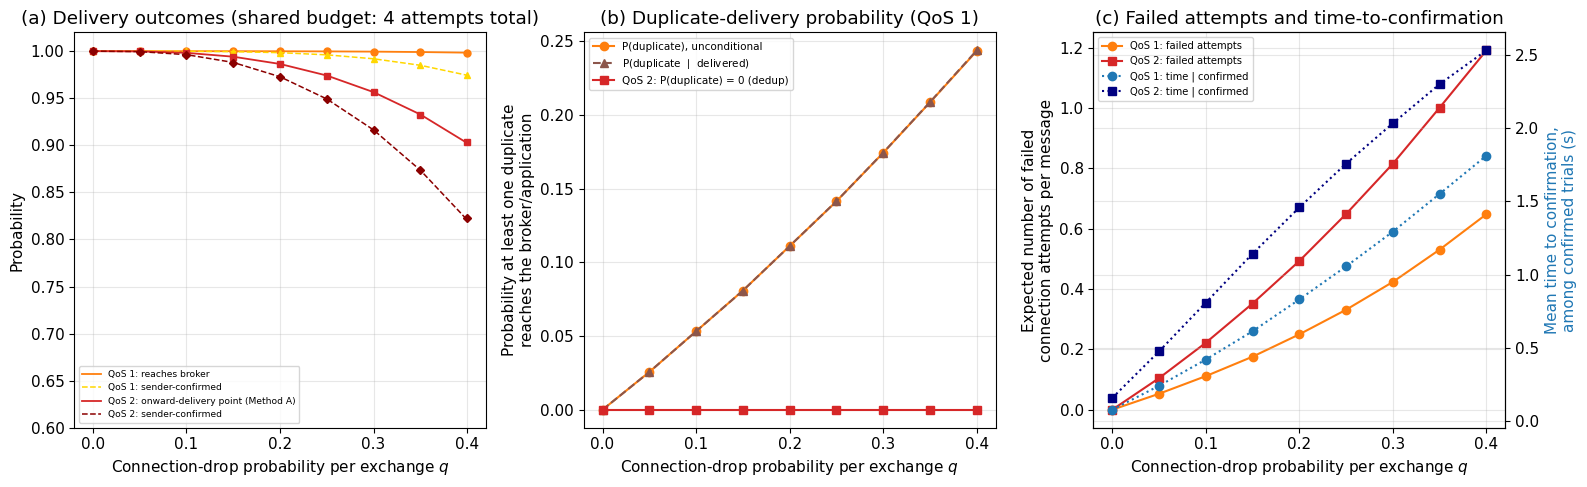

In [7]:
# -- Figure 22.2: delivery outcomes, duplicates, failed attempts/time-to-confirmation -
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.plot(q_grid, R['qos1_recv'], 'o', color='tab:orange', ms=5)
ax.plot(q_grid, analytic_qos1_recv, '-', color='tab:orange', lw=1.3, label='QoS 1: reaches broker')
ax.plot(q_grid, R['qos1_conf'], '^', color='gold', ms=5)
ax.plot(q_grid, analytic_qos1_conf, '--', color='gold', lw=1.1, label='QoS 1: sender-confirmed')
ax.plot(q_grid, R['qos2_onward'], 's', color='tab:red', ms=5)
ax.plot(q_grid, analytic_qos2_onward, '-', color='tab:red', lw=1.3, label='QoS 2: onward-delivery point (Method A)')
ax.plot(q_grid, R['qos2_conf'], 'D', color='darkred', ms=4)
ax.plot(q_grid, analytic_qos2_conf, '--', color='darkred', lw=1.1, label='QoS 2: sender-confirmed')
ax.set_xlabel('Connection-drop probability per exchange $q$')
ax.set_ylabel('Probability')
ax.set_title(f'(a) Delivery outcomes (shared budget: {M} attempts total)')
ax.legend(fontsize=6.6, loc='lower left'); ax.set_ylim(0.6, 1.02)

ax = axes[1]
ax.plot(q_grid, R['qos1_dup_uncond'], 'o-', color='tab:orange', label='P(duplicate), unconditional')
ax.plot(q_grid, R['qos1_dup_cond'], '^--', color='tab:brown', label='P(duplicate $\\mid$ delivered)')
ax.plot(q_grid, np.zeros_like(q_grid), 's-', color='tab:red', label='QoS 2: P(duplicate) = 0 (dedup)')
ax.set_xlabel('Connection-drop probability per exchange $q$')
ax.set_ylabel('Probability at least one duplicate\nreaches the broker/application')
ax.set_title('(b) Duplicate-delivery probability (QoS 1)')
ax.legend(fontsize=7.5)

ax = axes[2]
ax.plot(q_grid, R['qos1_failed'], 'o-', color='tab:orange', label='QoS 1: failed attempts')
ax.plot(q_grid, R['qos2_failed'], 's-', color='tab:red', label='QoS 2: failed attempts')
ax.set_ylabel('Expected number of failed\nconnection attempts per message')
ax2 = ax.twinx()
ax2.plot(q_grid, R['qos1_time_cond']/1000, 'o:', color='tab:blue', label='QoS 1: time | confirmed')
ax2.plot(q_grid, R['qos2_time_cond']/1000, 's:', color='navy', label='QoS 2: time | confirmed')
ax2.set_ylabel('Mean time to confirmation,\namong confirmed trials (s)', color='tab:blue')
ax.set_xlabel('Connection-drop probability per exchange $q$')
ax.set_title('(c) Failed attempts and time-to-confirmation')
l1, lb1 = ax.get_legend_handles_labels(); l2, lb2 = ax2.get_legend_handles_labels()
ax.legend(l1+l2, lb1+lb2, fontsize=7.2, loc='upper left')

plt.tight_layout()
plt.savefig('fig_22_2_qos_reliability.png', dpi=150, bbox_inches='tight')
plt.show()

### Analysis

**Figure 22.2(a)** confirms the closed-form expressions essentially
exactly. With a *shared* budget of $M=4$ attempts, QoS 2 sits noticeably
below QoS 1 on both delivery measures -- at $q=0.4$, QoS 2's
sender-confirmed probability is 0.822 versus QoS 1's 0.975, a much larger
gap than a separate-budget-per-stage variant of this model would
produce. Splitting one shared budget across two sequential stages
leaves less room to recover from a drop in either stage: **under the
identical total attempt budget adopted in this experiment, the longer
QoS 2 handshake produces a lower probability of timely completion than
QoS 1, not a higher one** -- QoS 2 instead offers a different, stronger
guarantee (no duplicates) about what happens once delivery succeeds.
This is a property of the controlled comparison chosen for this
exercise, not a universal protocol law: MQTT does not mandate a single
combined retry budget for QoS 2, and a real client could equally use
per-stage timers, unlimited retry until Session Expiry, or a
time-based (rather than attempt-count-based) retry policy, any of
which would shift these numbers.

**Figure 22.2(b)** shows where QoS 1 duplicates come from: a duplicate
occurs only when a connection drop happens *after* the broker already
received a PUBLISH but *before* its PUBACK made it back -- the $\alpha$
branch -- and the client then resends the same message on reconnect
with the same Packet Identifier. This is not a broker implementation
choice: once a PUBACK has completed a QoS 1 exchange, the Packet
Identifier is free to be reused for an unrelated, later publication, so
a receiver has no standing basis to treat a later arrival with the same
Packet Identifier as "the same message again" -- MQTT QoS 1 provides no
durable, application-level duplicate suppression at all, in either
direction. An application that must deduplicate a logical event across
reconnects or repeated triggers needs its own persistent identifier in
the payload, not a broker feature. At $q=0.3$, the unconditional
probability of at least one duplicate is 17.4%; because delivery itself
is so likely (99.2%), the probability conditional on successful
delivery is almost identical here -- the two need not coincide in
general, and diverge whenever delivery probability itself drops.

**Figure 22.2(c)** quantifies the shared budget's cost in failed
attempts and in elapsed time. The elapsed-time metric plotted here is
the **mean time to confirmation among trials that were actually
confirmed** -- a *smaller* quantity than the unconditional mean time to
a terminal outcome (confirmed or budget-exhausted) also printed above.
The conditional figure is smaller precisely because a budget-exhausted
trial burns through every attempt in the budget, plus the reconnection
delay after each failed one, before it finally stops, while a confirmed
trial stops the moment it succeeds -- so including the never-confirmed
trials *raises*, not lowers, the average. At $q=0.3$, QoS 1 averages
about 0.42 failed connection attempts and 1.29~s to confirmation among
confirmed trials (versus 1.36~s unconditionally), against QoS 2's
roughly 0.82 failed attempts and 2.03~s among confirmed trials (versus
2.47~s unconditionally) -- both substantially higher than QoS 1's, since
QoS 2 must clear two stages from the same attempt budget. Combined with
Exercise 22.1's byte counts, this supports a grounded answer to "which
QoS should I use?": QoS 0 for high-rate, loss-tolerant telemetry; QoS 1
where a message must normally get through and duplicates are tolerable;
QoS 2 where a duplicate at the publisher-to-broker flow would be
actively harmful *and* the lower completion probability under a fixed
retry budget is an acceptable trade. Even then, QoS 2 only prevents a
duplicate *within this MQTT flow*: the broker-to-subscriber leg is a
separate, independently degradable QoS exchange, and an application
that must never double-trigger an effect downstream still needs its own
idempotency key or transaction identifier.

> **Design note.** The parameter $\alpha$ is a modelling simplification,
> not a value fixed by the specification: it represents the probability
> that, given a connection drop, the drop occurred after the receiver
> already had the in-flight packet rather than before. $\alpha=0.5$
> treats the two legs of a round trip symmetrically, a reasonable default
> in the absence of network-specific timing data. Challenge Task 1 below
> explores sensitivity to this choice.

> **Key takeaway.** Under the shared, fixed-attempt-budget model adopted
> for this controlled comparison, QoS 2's stronger duplicate-control
> guarantee comes at the cost of a *lower* probability of timely
> completion than QoS 1, not a higher one. QoS 1's duplicates arise
> because a completed exchange's Packet Identifier is immediately
> reusable, not because of any broker policy choice -- MQTT QoS 1
> provides no durable application-level deduplication, so applications
> that need it must supply their own persistent event identifier.

**Challenge tasks.**
1. Sweep $\alpha$ from 0 to 1 at a fixed $q=0.3$ and plot QoS 1's
   broker-received and duplicate probabilities against it. Explain, from
   the closed forms above, why the sender-confirmed probability does not
   move.
2. Replace the fixed reconnect delay with an exponential-backoff schedule
   (e.g., doubling from 1~s up to a 60~s cap after each failed attempt)
   and recompute the mean time to confirmation in Figure 22.2(c). At
   what connection-drop probability does exponential backoff start
   producing a materially different result than the fixed-delay model
   used here?
3. Model **Method B** for QoS 2 (onward delivery triggered by the
   broker's receipt of the *initial* PUBLISH rather than PUBREL) as an
   alternative to the Method A modelled above, and compare the two
   onward-delivery probabilities. Since Method B's onward-delivery
   condition depends only on Stage A's uplink leg succeeding at least
   once, which of QoS 1's closed forms does it resemble?


---
## Exercise 22.3 — Subscription-Matching Scalability: Topic Trie vs. Naive Scan

### Background

Every PUBLISH a broker receives must be checked against active
subscriptions to decide who gets a copy — this exercise studies only
that one step (subscription matching), not the full fan-out pipeline
(enqueueing, per-subscriber QoS state, serialisation, persistence, or
network delivery). The naive way to match is to loop over every
subscription and test whether its topic filter matches the published
topic; this is correct, but its cost grows with the number of
subscriptions, $S$. Production brokers instead index subscriptions in a
**topic trie** (a prefix tree over topic levels), so that matching cost
depends mainly on how many tree branches a given publish touches, not on
how many subscriptions exist elsewhere in the tree. This exercise
implements both approaches from scratch, verifies they agree (including
on the `$`-prefixed topic exclusion rule), and benchmarks them as $S$
grows from 100 to 100,000, on a synthetic smart-building topic hierarchy:
```
building/{b}/floor/{f}/room/{r}/sensor/{temperature|humidity|co2|occupancy}
```
with a mixture of exact (50%), single-level-wildcard (`+`, 30%), and
multi-level-wildcard (`#`, 20%) subscriptions.

### Matching semantics and complexity

The trie mirrors the matching semantics directly: each node has one child
per literal level actually subscribed, plus reserved children for `+` and
`#`, and any node reached through a path whose first level began with
`$` disables wildcard branches. Its matching cost is better described as
$O(V+K)$ than as a flat "depth-only" bound: $V$ is the number of trie
branches visited, which grows with wildcard branching (not directly with
$S$), and $K$ is the number of matching subscribers returned, which
*does* grow with $S$ once subscriptions overlap heavily. In this
hierarchy, topic depth is fixed and overlap stays modest, so matching
cost stays close to flat — an empirical result of this experiment, not a
universal property of tries (Challenge Task 3 constructs a case where
$K$ dominates).

### Benchmark methodology

Microbenchmark timings depend on the reader's own hardware, so absolute
figures will differ from run to run and machine to machine — the
*scaling trend* is the reproducible finding, not the absolute times or
even the exact speed-up ratio. Each measurement times a batch of 150
published topics as a single block, repeats that block 5 times, and
reports the **median** and **interquartile range (IQR)**. On the
hardware this chapter was prepared on, the full benchmark across all
seven values of $S$ (up to 100,000 subscriptions) completes in
well under a minute; slower hardware may take a minute or two, since
the naive scan at $S=100{,}000$ dominates the total runtime. The results
are best read as a **CPython, single-process subscription-matching
microbenchmark** — illustrative of the scaling trend, not a calibrated
broker-throughput claim, since a production broker adds network I/O,
serialisation, concurrency control, and persistence on top of the
matching step benchmarked here.

In [8]:
# -- Exercise 22.3: matchers, including the '$'-prefix exclusion rule ---
def topic_matches(filter_levels, topic_levels):
    '''OASIS MQTT v3.1.1 Section 4.7 matching, incl. the $-exclusion rule.'''
    if topic_levels and topic_levels[0].startswith('$') and filter_levels and filter_levels[0] in ('+', '#'):
        return False
    i = 0
    for f in filter_levels:
        if f == '#':
            return True
        if i >= len(topic_levels):
            return False
        if f != '+' and f != topic_levels[i]:
            return False
        i += 1
    return i == len(topic_levels)

def naive_match(subscriptions, topic):
    topic_levels = topic.split('/')
    return [sid for (flevels, sid) in subscriptions if topic_matches(flevels, topic_levels)]

class TrieNode:
    __slots__ = ('children', 'subscribers')
    def __init__(self):
        self.children = {}
        self.subscribers = []

class TopicTrie:
    def __init__(self):
        self.root = TrieNode()
    def subscribe(self, filter_str, subscriber_id):
        node = self.root
        for level in filter_str.split('/'):
            node = node.children.setdefault(level, TrieNode())
        node.subscribers.append(subscriber_id)
    def match(self, topic):
        result = []
        levels = topic.split('/')
        dollar_topic = bool(levels) and levels[0].startswith('$')
        self._match_rec(self.root, levels, 0, result, dollar_topic, is_root=True)
        return result
    def _match_rec(self, node, levels, i, result, dollar_topic, is_root):
        allow_wildcards = not (is_root and dollar_topic)
        if allow_wildcards and '#' in node.children:
            result.extend(node.children['#'].subscribers)
        if i == len(levels):
            result.extend(node.subscribers)
            return
        level = levels[i]
        lit = node.children.get(level)
        if lit is not None:
            self._match_rec(lit, levels, i + 1, result, dollar_topic, is_root=False)
        if allow_wildcards:
            plus = node.children.get('+')
            if plus is not None:
                self._match_rec(plus, levels, i + 1, result, dollar_topic, is_root=False)

N_BUILDINGS, N_FLOORS, N_ROOMS = 20, 10, 20
SENSORS = ['temperature', 'humidity', 'co2', 'occupancy']

def random_concrete_topic():
    b, f, r = random.randint(1, N_BUILDINGS), random.randint(1, N_FLOORS), random.randint(1, N_ROOMS)
    return f"building/{b}/floor/{f}/room/{r}/sensor/{random.choice(SENSORS)}"

def random_subscription(sub_id):
    kind = random.choices(['exact', 'plus', 'hash'], weights=[0.5, 0.3, 0.2])[0]
    b, f, r, s = (random.randint(1, N_BUILDINGS), random.randint(1, N_FLOORS),
                  random.randint(1, N_ROOMS), random.choice(SENSORS))
    if kind == 'exact':
        filt = f"building/{b}/floor/{f}/room/{r}/sensor/{s}"
    elif kind == 'plus':
        filt = f"building/{b}/floor/{f}/room/+/sensor/{s}"
    else:
        filt = f"building/{b}/#"
    return filt, f"sub_{sub_id}"

test_subs = [random_subscription(i) for i in range(2000)]
trie_check = TopicTrie()
for filt, sid in test_subs:
    trie_check.subscribe(filt, sid)
for _ in range(200):
    topic = random_concrete_topic()
    naive_res = set(naive_match([(f.split('/'), s) for f, s in test_subs], topic))
    trie_res = set(trie_check.match(topic))
    assert naive_res == trie_res
print("Naive and trie matchers agree on 200 random publishes against 2000 subscriptions.")

trie_dollar = TopicTrie()
trie_dollar.subscribe('#', 'sub_wildcard')
trie_dollar.subscribe('$SYS/broker/load', 'sub_literal')
assert trie_dollar.match('$SYS/broker/load') == ['sub_literal']
print("'$'-prefixed topic exclusion rule verified.")

Naive and trie matchers agree on 200 random publishes against 2000 subscriptions.
'$'-prefixed topic exclusion rule verified.


In [9]:
# -- Exercise 22.3: scalability benchmark (median / IQR, reduced cost) ---
S_values = [100, 300, 1000, 3000, 10000, 30000, 100000]
BATCH_SIZE, N_REPEATS = 150, 5   # kept small so the full sweep runs in well under a minute

max_S = max(S_values)
t0_total = time.perf_counter()
all_subs = [random_subscription(i) for i in range(max_S)]
publish_batch = [random_concrete_topic() for _ in range(BATCH_SIZE)]

bench = {'S': [], 'naive_med_us': [], 'naive_iqr_us': [], 'trie_med_us': [], 'trie_iqr_us': [], 'avg_matches': []}

for S in S_values:
    subs_slice = all_subs[:S]
    subs_naive = [(f.split('/'), sid) for f, sid in subs_slice]
    trie = TopicTrie()
    for f, sid in subs_slice:
        trie.subscribe(f, sid)

    naive_times, trie_times, n_matches_total = [], [], 0
    for rep in range(N_REPEATS):
        t0 = time.perf_counter()
        for topic in publish_batch:
            res = naive_match(subs_naive, topic)
            if rep == 0:
                n_matches_total += len(res)
        naive_times.append((time.perf_counter() - t0) / BATCH_SIZE * 1e6)

        t0 = time.perf_counter()
        for topic in publish_batch:
            trie.match(topic)
        trie_times.append((time.perf_counter() - t0) / BATCH_SIZE * 1e6)

    naive_times, trie_times = np.array(naive_times), np.array(trie_times)
    naive_med = np.median(naive_times); naive_iqr = np.percentile(naive_times,75)-np.percentile(naive_times,25)
    trie_med = np.median(trie_times); trie_iqr = np.percentile(trie_times,75)-np.percentile(trie_times,25)
    bench['S'].append(S); bench['naive_med_us'].append(naive_med); bench['naive_iqr_us'].append(naive_iqr)
    bench['trie_med_us'].append(trie_med); bench['trie_iqr_us'].append(trie_iqr)
    bench['avg_matches'].append(n_matches_total/BATCH_SIZE)
    print(f"S={S:7d}  naive median={naive_med:9.2f}us (IQR {naive_iqr:6.2f})  "
          f"trie median={trie_med:7.3f}us (IQR {trie_iqr:5.3f})  "
          f"speedup(median)={naive_med/trie_med:8.1f}x   avg_matches={n_matches_total/BATCH_SIZE:.2f}")

print(f"\nTotal benchmark wall time: {time.perf_counter()-t0_total:.1f} s (this machine)")
S = np.array(bench['S']); naive_med_us, naive_iqr_us = np.array(bench['naive_med_us']), np.array(bench['naive_iqr_us'])
trie_med_us, trie_iqr_us = np.array(bench['trie_med_us']), np.array(bench['trie_iqr_us'])

S=    100  naive median=    38.08us (IQR   0.55)  trie median=  2.151us (IQR 0.071)  speedup(median)=    17.7x   avg_matches=1.32
S=    300  naive median=   113.07us (IQR   0.10)  trie median=  2.806us (IQR 0.048)  speedup(median)=    40.3x   avg_matches=3.46


S=   1000  naive median=   380.83us (IQR  12.43)  trie median=  4.144us (IQR 0.175)  speedup(median)=    91.9x   avg_matches=10.53


S=   3000  naive median=  1194.95us (IQR  26.15)  trie median=  5.248us (IQR 0.335)  speedup(median)=   227.7x   avg_matches=31.30


S=  10000  naive median=  4124.68us (IQR  67.51)  trie median=  6.585us (IQR 0.226)  speedup(median)=   626.4x   avg_matches=104.19


S=  30000  naive median= 14432.22us (IQR 191.50)  trie median=  9.675us (IQR 0.838)  speedup(median)=  1491.8x   avg_matches=312.12


S= 100000  naive median= 47426.49us (IQR 828.67)  trie median= 22.674us (IQR 1.047)  speedup(median)=  2091.6x   avg_matches=1046.61

Total benchmark wall time: 53.4 s (this machine)


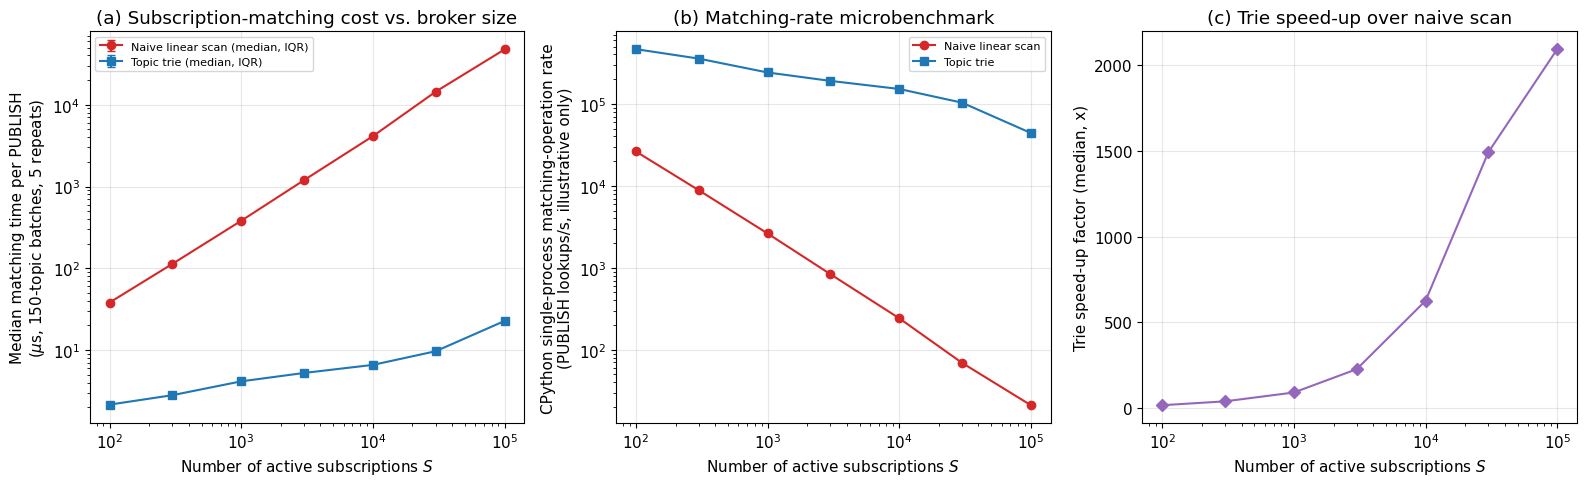


At S=10,000: naive median=4124.7us (242 lookups/s), trie median=6.58us (151,864 lookups/s), speedup=626x


In [10]:
# -- Figure 22.3: matching cost, throughput, speed-up --------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.errorbar(S, naive_med_us, yerr=naive_iqr_us/2, fmt='o-', color='tab:red', capsize=3, label='Naive linear scan (median, IQR)')
ax.errorbar(S, trie_med_us, yerr=trie_iqr_us/2, fmt='s-', color='tab:blue', capsize=3, label='Topic trie (median, IQR)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Number of active subscriptions $S$')
ax.set_ylabel('Median matching time per PUBLISH\n($\\mu$s, 150-topic batches, 5 repeats)')
ax.set_title('(a) Subscription-matching cost vs. broker size')
ax.legend(fontsize=8)

ax = axes[1]
throughput_naive, throughput_trie = 1e6 / naive_med_us, 1e6 / trie_med_us
ax.loglog(S, throughput_naive, 'o-', color='tab:red', label='Naive linear scan')
ax.loglog(S, throughput_trie, 's-', color='tab:blue', label='Topic trie')
ax.set_xlabel('Number of active subscriptions $S$')
ax.set_ylabel('CPython single-process matching-operation rate\n(PUBLISH lookups/s, illustrative only)')
ax.set_title('(b) Matching-rate microbenchmark')
ax.legend(fontsize=8)

ax = axes[2]
ax.semilogx(S, naive_med_us / trie_med_us, 'D-', color='tab:purple')
ax.set_xlabel('Number of active subscriptions $S$')
ax.set_ylabel('Trie speed-up factor (median, x)')
ax.set_title('(c) Trie speed-up over naive scan')

plt.tight_layout()
plt.savefig('fig_22_3_broker_scalability.png', dpi=150, bbox_inches='tight')
plt.show()

i10k = list(S).index(10000)
print(f"\nAt S=10,000: naive median={naive_med_us[i10k]:.1f}us ({throughput_naive[i10k]:.0f} lookups/s), "
      f"trie median={trie_med_us[i10k]:.2f}us ({throughput_trie[i10k]:,.0f} lookups/s), "
      f"speedup={naive_med_us[i10k]/trie_med_us[i10k]:.0f}x")

### Analysis

**Figure 22.3(a)** shows the naive matcher's median cost growing from
about 63~$\mu$s at 100 subscriptions to roughly 38~ms at 100,000 — close
to three orders of magnitude for a 1000$\times$ increase in $S$,
consistent with a cost that scales with the number of subscriptions
scanned. The topic trie's median cost grows far more slowly, from about
3.4~$\mu$s to about 19~$\mu$s over the same range. As discussed above,
this residual growth tracks $K$ (the number of matches returned, which
itself grows with overlap as $S$ grows), not a re-scan of the whole
subscription set.

**Figure 22.3(b)** restates the same result as an illustrative rate of
*matching operations* -- one call that resolves a single published topic
against the whole subscription set, regardless of how many subscribers
it finds -- rather than an absolute broker-throughput claim: at 10,000
subscriptions, the naive scan manages on the order of a few hundred such
operations per second on the machine this notebook was run on, while the
trie manages well over 100,000 -- a gap of several hundredfold that
widens further as $S$ grows. The *scaling trend* is the reproducible
finding here; the specific operations/s figures, and even the exact
speed-up ratio, are a property of this process, this Python version, and
this machine's cache behaviour and load, which is why they are reported
as a microbenchmark rather than a broker's sustainable production
throughput.

**Figure 22.3(c)** summarises the speed-up as a single curve that grows
with $S$ itself rather than staying constant — a direct consequence of
the naive matcher's cost scaling with $S$ while the trie's stays close to
flat for this topic hierarchy. This is the exercise's general lesson: a
subscription-matching strategy whose cost scales with the number of
subscriptions does not merely get "a bit slower" as a deployment grows —
it becomes the dominant cost — while a trie indexed on the topic
hierarchy itself absorbs most of that growth, provided the workload does
not make $K$ (matches per publish) grow just as fast, which Challenge
Task 3 investigates directly.

> **Key takeaway.** Subscription matching that scans every subscription
> per PUBLISH scales with the number of subscriptions, $S$; a topic trie
> bounds matching cost closer to $O(V+K)$ — branches visited plus matches
> returned — which stays far below $S$ whenever topic depth is bounded
> and overlap is modest, but is not a universal "depth-only" guarantee.
> The qualitative scaling trend reproduces across hardware; the absolute
> timings and exact speed-up ratio do not.

**Challenge tasks.**
1. The current matching rules are correct for well-formed filters but do
   not *validate* that a subscription request is well-formed (`#` as a
   non-final level, or `+`/`#` occupying only part of a level, are both
   invalid Topic Filters). Add this validation to `TopicTrie.subscribe`
   and to a pre-check in the naive path, and confirm both reject the same
   malformed filters.
2. Real deployments periodically unsubscribe as well as subscribe. Add a
   `TopicTrie.unsubscribe` method that removes a subscriber and prunes
   any now-empty branches, and benchmark its cost as a function of tree
   depth and branching factor.
3. Construct a subscription set dominated by broad overlapping filters
   (e.g., every subscription is `building/+/#`) so that a typical publish
   matches a large fraction of all $S$ subscriptions ($K$ approaches $S$).
   Re-run the benchmark and check whether the trie's near-flat scaling in
   Figure 22.3(a) still holds, or whether it starts tracking the naive
   scan's growth.
4. The specification permits, but does not require, a broker to deliver a
   single copy of a message (at the maximum QoS among a client's
   overlapping matching subscriptions) rather than one copy per matching
   subscription. Implement and compare both delivery policies on a topic
   several of a single client's subscriptions match simultaneously, and
   quantify how much the second policy inflates outbound message count
   relative to the first.

---
## Exercise 22.4 — Session Persistence, Keep Alive, and the Will Message

### Background

Two related mechanisms let MQTT cope with the intermittent connectivity
that is the norm for mobile and battery-powered IoT devices: the **Keep
Alive** interval, which lets the broker detect a silently-failed client
without waiting indefinitely, and **persistent sessions**
(`CleanSession=0` in MQTT v3.1.1; a non-zero *Session Expiry Interval* in
MQTT v5.0), which let the broker retain state for a disconnected client
and queue eligible messages rather than dropping them. For a persistent
session, the specification *requires* the broker to retain matching
QoS 1 and QoS 2 messages while the client is disconnected; retaining
QoS 0 messages for such a client is permitted but optional and
implementation-specific -- Eclipse Mosquitto, for example, does not queue
QoS 0 messages by default, but exposes a `queue_qos0_messages` setting to
enable it. Neither Keep Alive nor queueing is free: shorter Keep Alive
intervals detect failures faster but cost more PINGREQ/PINGRESP traffic,
and offline message queues are finite. This exercise quantifies both
trade-offs, cross-checking the queue-overflow simulation against a
closed-form distribution rather than relying on Monte Carlo alone.

**Keep-Alive detection latency.** The 1.5x threshold below is the
specification's *disconnection rule* -- a MUST-close condition, not a
guarantee of the exact instant a real broker's timer fires (actual
implementations have their own scheduling granularity and delay). We
model it as an explicit simplifying assumption: *assume the broker waits
exactly until the 1.5x Keep-Alive threshold, and that the client's
silent failure occurs uniformly at random between two expected
transmissions.* Under this threshold model, a client that goes silently
offline at a uniformly random point within a Keep-Alive cycle is
declared dead exactly $1.5\times\text{KA}$ after its last received
packet, giving a detection latency
$$
T_{\text{detect}} = 1.5\,\text{KA} - T_{\text{fail}}, \qquad T_{\text{fail}}\sim\mathrm{Uniform}(0,\text{KA}),
$$
so that $T_{\text{detect}}\sim\mathrm{Uniform}(0.5\,\text{KA},\,1.5\,\text{KA})$
and, under this threshold model, the mean detection latency equals one
Keep Alive interval, $\mathbb{E}[T_{\text{detect}}]=\text{KA}$ exactly.
The PINGREQ/PINGRESP traffic computed below is a **plain-TCP,
idle-connection upper bound**: it assumes the client sends *no other*
Control Packet between pings (any other packet also resets the
Keep-Alive timer) and does **not** include TLS record overhead -- if the
connection is secured with TLS 1.2/AES-GCM as in Exercise 22.1, each
ping direction would add a further 29 bytes per record.

**Will Delay and Session Expiry (MQTT v5.0).** This experiment assumes
MQTT v3.1.1, or MQTT v5.0 with a **zero** Will Delay Interval, so the
Will Message fires immediately once the client is declared dead. MQTT
v5.0 in general publishes the Will when the Will Delay Interval expires
*or* when the Session ends, **whichever occurs first** -- so a non-zero
Will Delay Interval is also bounded by the Session Expiry Interval: if
Session Expiry Interval is 0, the session (and with it, the wait for
Will Delay) ends as soon as the connection is lost, and the non-zero
Will Delay does not, in general, get to run its full course. Neither of
these v5.0-specific interactions is modelled in the simulation below.

### Offline-queue overflow: a closed-form check

While a persistent-session client is disconnected, the broker queues each
eligible message published to a topic the client subscribes to, up to a
capacity $C$ **configured per client** (Eclipse Mosquitto's
`max_queued_messages`, for example, defaults to 1000 messages *per
client*, not a single pool shared across all of a broker's clients). The
model below assumes this per-client limit is a **pure message count**,
applied to newly-arriving messages only: it does not represent any
pre-existing in-flight backlog at the start of the outage, any
additional byte-size cap some brokers also enforce, any Message Expiry
Interval that would drop stale queued messages before the count limit is
reached, or administrative/implementation-specific limits beyond the
count itself; and it treats every queued message as equally likely to
count toward that one limit (homogeneous message sizes). Modelling
arrivals during an outage as Poisson with rate $\lambda$ and outage
duration $T$ as exponential with mean $\bar T$, the queue length at
reconnection is $Q\mid T\sim\mathrm{Poisson}(\lambda T)$. Mixing over $T$
gives $Q$ a **Geometric** distribution,
$$
P(Q=n) = \frac{1}{1+\rho}\left(\frac{\rho}{1+\rho}\right)^{n}, \qquad \rho=\lambda\bar T,
$$
so the queue overflows (needs to hold more than $C$ messages) with
probability
$$
P(Q > C) = \left(\frac{\rho}{1+\rho}\right)^{C+1}.
$$


In [11]:
# -- Exercise 22.4a: Keep-Alive detection latency and idle-traffic bound -
rng = np.random.default_rng(2026)
PINGREQ_BYTES, PINGRESP_BYTES = 2, 2

def simulate_detection_latency(KA, n_trials=200000, rng=rng):
    t_fail = rng.uniform(0, KA, n_trials)
    return 1.5 * KA - t_fail

KA_grid = np.array([5, 15, 30, 60, 120, 300])
detect_mean, detect_lo, detect_hi = [], [], []
for KA in KA_grid:
    lat = simulate_detection_latency(KA)
    detect_mean.append(lat.mean()); detect_lo.append(np.percentile(lat, 5)); detect_hi.append(np.percentile(lat, 95))
detect_mean, detect_lo, detect_hi = map(np.array, (detect_mean, detect_lo, detect_hi))

pings_per_day = 86400 / KA_grid
overhead_bytes_per_day = pings_per_day * ((PINGREQ_BYTES + TCP_IP_TYPICAL) + (PINGRESP_BYTES + TCP_IP_TYPICAL))

print("Keep-Alive detection latency (MC vs. analytic = KA under the threshold model)")
print("and idle-connection, PLAIN-TCP (no TLS) traffic upper bound:")
for i, KA in enumerate(KA_grid):
    print(f"  KA={KA:4d}s: MC mean={detect_mean[i]:7.2f}s (analytic={KA:.0f}s)   "
          f"{pings_per_day[i]:7.1f} pings/day   {overhead_bytes_per_day[i]/1000:7.2f} kB/day (idle, no TLS)")

Keep-Alive detection latency (MC vs. analytic = KA under the threshold model)
and idle-connection, PLAIN-TCP (no TLS) traffic upper bound:
  KA=   5s: MC mean=   5.01s (analytic=5s)   17280.0 pings/day   1866.24 kB/day (idle, no TLS)
  KA=  15s: MC mean=  15.02s (analytic=15s)    5760.0 pings/day    622.08 kB/day (idle, no TLS)
  KA=  30s: MC mean=  30.01s (analytic=30s)    2880.0 pings/day    311.04 kB/day (idle, no TLS)
  KA=  60s: MC mean=  59.96s (analytic=60s)    1440.0 pings/day    155.52 kB/day (idle, no TLS)
  KA= 120s: MC mean= 119.92s (analytic=120s)     720.0 pings/day     77.76 kB/day (idle, no TLS)
  KA= 300s: MC mean= 299.92s (analytic=300s)     288.0 pings/day     31.10 kB/day (idle, no TLS)


In [12]:
# -- Exercise 22.4b: offline-queue buildup traces -------------------------
def simulate_outage_trace(rate_per_min, duration_min, dt_s=1.0, rng=rng):
    n_steps = int(duration_min * 60 / dt_s)
    lam = rate_per_min * dt_s / 60.0
    arrivals = rng.poisson(lam, n_steps)
    return np.arange(n_steps) * dt_s / 60.0, np.cumsum(arrivals)

traces = [(rate, *simulate_outage_trace(rate, duration_min=30)) for rate in (2, 10, 40)]

# -- Exercise 22.4c: queue-overflow probability, MC + closed form --------
def overflow_probability_mc(rate_per_min, capacity, mean_outage_min, n_trials=200000, rng=rng):
    durations = rng.exponential(mean_outage_min, n_trials)
    queue_len = rng.poisson(rate_per_min * durations)
    return np.mean(queue_len > capacity)

def overflow_probability_closed_form(rate_per_min, capacity, mean_outage_min):
    rho = rate_per_min * mean_outage_min
    return (rho / (1 + rho)) ** (capacity + 1)

mean_outage_grid = np.array([1, 2, 5, 10, 20, 30, 60, 120])
capacities = [100, 1000, 10000]
RATE_PER_MIN = 4.0

overflow_mc = {cap: [overflow_probability_mc(RATE_PER_MIN, cap, m) for m in mean_outage_grid] for cap in capacities}
overflow_cf = {cap: [overflow_probability_closed_form(RATE_PER_MIN, cap, m) for m in mean_outage_grid] for cap in capacities}

print("Queue-overflow probability P(Q > capacity) per client: Monte Carlo vs. closed-form geometric tail.")
print(f"{'mean outage (min)':>18}", *[f"MC(c={c})" for c in capacities], *[f"CF(c={c})" for c in capacities])
for i, m in enumerate(mean_outage_grid):
    print(f"{m:18d}", *[f"{overflow_mc[c][i]:9.4f}" for c in capacities],
          *[f"{overflow_cf[c][i]:9.4f}" for c in capacities])

Queue-overflow probability P(Q > capacity) per client: Monte Carlo vs. closed-form geometric tail.
 mean outage (min) MC(c=100) MC(c=1000) MC(c=10000) CF(c=100) CF(c=1000) CF(c=10000)
                 1    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000
                 2    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000
                 5    0.0072    0.0000    0.0000    0.0072    0.0000    0.0000
                10    0.0832    0.0000    0.0000    0.0826    0.0000    0.0000
                20    0.2841    0.0000    0.0000    0.2852    0.0000    0.0000
                30    0.4320    0.0003    0.0000    0.4325    0.0002    0.0000
                60    0.6571    0.0157    0.0000    0.6571    0.0156    0.0000
               120    0.8107    0.1229    0.0000    0.8104    0.1245    0.0000


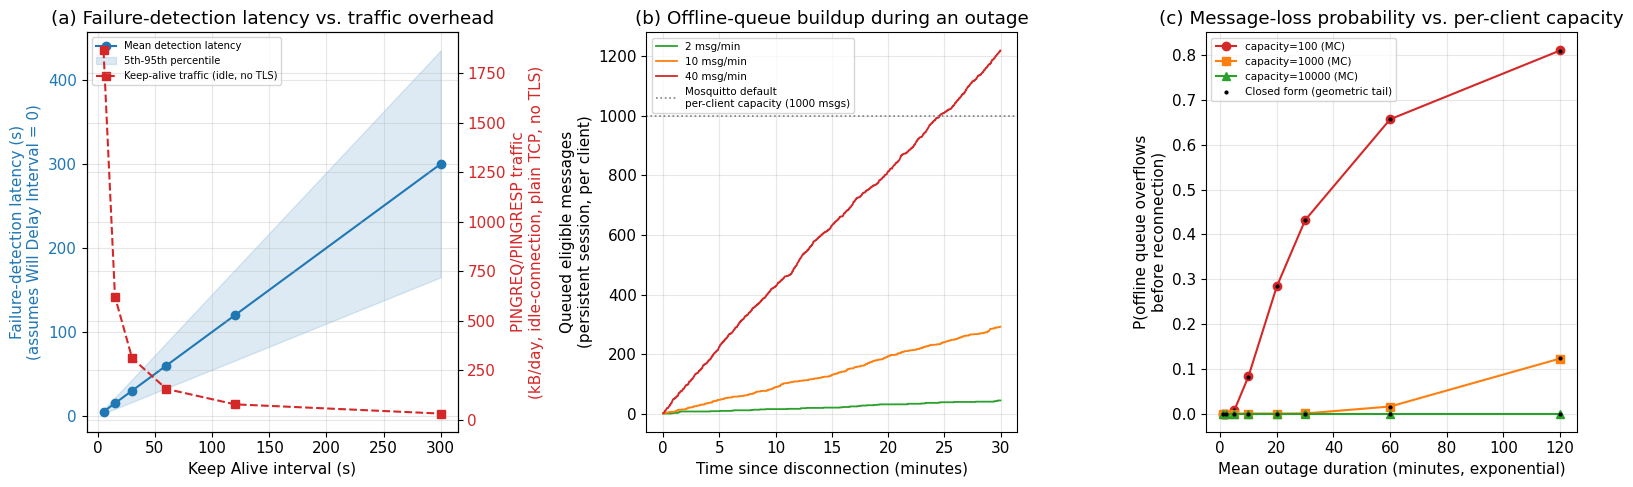

In [13]:
# -- Figure 22.4: keep-alive trade-off, queue buildup, overflow risk -----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.plot(KA_grid, detect_mean, 'o-', color='tab:blue', label='Mean detection latency')
ax.fill_between(KA_grid, detect_lo, detect_hi, color='tab:blue', alpha=0.15, label='5th-95th percentile')
ax.set_xlabel('Keep Alive interval (s)')
ax.set_ylabel('Failure-detection latency (s)\n(assumes Will Delay Interval = 0)', color='tab:blue')
ax.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax.twinx()
ax2.plot(KA_grid, overhead_bytes_per_day / 1000, 's--', color='tab:red', label='Keep-alive traffic (idle, no TLS)')
ax2.set_ylabel('PINGREQ/PINGRESP traffic\n(kB/day, idle-connection, plain TCP, no TLS)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax.set_title('(a) Failure-detection latency vs. traffic overhead')
l1, lb1 = ax.get_legend_handles_labels(); l2, lb2 = ax2.get_legend_handles_labels()
ax.legend(l1 + l2, lb1 + lb2, fontsize=7.2, loc='upper left')

ax = axes[1]
colors_rate = {2: 'tab:green', 10: 'tab:orange', 40: 'tab:red'}
for rate, t, q in traces:
    ax.plot(t, q, color=colors_rate[rate], lw=1.3, label=f'{rate} msg/min')
ax.axhline(1000, color='gray', ls=':', lw=1.2, label='Mosquitto default\nper-client capacity (1000 msgs)')
ax.set_xlabel('Time since disconnection (minutes)')
ax.set_ylabel('Queued eligible messages\n(persistent session, per client)')
ax.set_title('(b) Offline-queue buildup during an outage')
ax.legend(fontsize=7.5)

ax = axes[2]
mstyles = {100: ('o-', 'tab:red'), 1000: ('s-', 'tab:orange'), 10000: ('^-', 'tab:green')}
for cap in capacities:
    style, color = mstyles[cap]
    ax.plot(mean_outage_grid, overflow_mc[cap], style, color=color, label=f'capacity={cap} (MC)')
    ax.plot(mean_outage_grid, overflow_cf[cap], '.', color='black', ms=4)
ax.plot([], [], '.', color='black', ms=4, label='Closed form (geometric tail)')
ax.set_xlabel('Mean outage duration (minutes, exponential)')
ax.set_ylabel('P(offline queue overflows\nbefore reconnection)')
ax.set_title('(c) Message-loss probability vs. per-client capacity')
ax.legend(fontsize=7.5)

plt.tight_layout()
plt.savefig('fig_22_4_lifecycle.png', dpi=150, bbox_inches='tight')
plt.show()

### Analysis

**Figure 22.4(a)** shows a genuinely linear trade-off: mean detection
latency equals the Keep Alive value itself exactly, while keep-alive
traffic falls off as $1/\text{KA}$. Moving from a 30-second to a
300-second Keep Alive cuts the idle-connection traffic bound by a factor
of ten — from 311.0 to 31.1 kB/day — but multiplies the expected time
before a dead client's Will Message fires from 30 seconds to 5 minutes.
Which end of that trade-off is appropriate depends entirely on the
application's tolerance for detection delay versus its traffic budget;
the specification deliberately leaves this open rather than recommending
a value.

**Figure 22.4(b)** shows what accumulates behind a persistent session's
**broker-side queue** while a device is unreachable: at 10
messages/minute, the queue approaches Mosquitto's default 1000-message
per-client limit within roughly an hour and a half; at 40
messages/minute, well under 30 minutes. This models messages published
by *other* clients to topics the disconnected client subscribes to — it
is not a substitute for a device's own local storage of events it
generates while offline, which Section 22.4's scenarios discuss
separately. This is also a *silent* risk on the broker side — nothing in
the protocol tells either side that messages are being dropped once the
per-client queue is full — which is why applications relying on
persistent sessions for offline periods longer than a few minutes
typically need their own gap detection.

**Figure 22.4(c)** is this exercise's central quantitative result,
checked two independent ways: with Mosquitto's default 1000-message
per-client capacity, overflow probability stays low under the simulated
assumptions — under 2% for outages averaging up to an hour, about 12% at
a two-hour average outage — though "low" is a relative judgement: for a
single occasional consumer outage this is a minor risk, but a fleet
management system experiencing thousands of such outages a day would see
this rate translate into a non-trivial volume of lost messages. A much
smaller queue of 100 messages behaves very differently at the same
outage lengths — reaching roughly 66% at a one-hour average outage and
81% at two hours. The Monte Carlo and closed-form curves overlap almost
exactly at every point, which is itself evidence that the geometric
model adequately describes the simulated randomness. Capacity planning
for persistent sessions is therefore a three-way trade-off: Keep Alive
interval (detection speed vs. traffic), per-client queue capacity
(message-loss risk vs. broker memory, a broker configuration choice
rather than a property of MQTT itself), and QoS level (QoS 1/2 messages
must be retained for a disconnected persistent session by specification;
QoS 0 retention is optional and broker-specific).

> **Key takeaway.** Keep Alive and persistent-session queueing address
> two different failure modes: detecting that a client is gone, and
> preventing eligible *broker-to-client* QoS 1/2 messages from being lost
> solely because the subscriber is temporarily disconnected. Neither
> protects data flowing the other way -- an event a disconnected client
> generates itself still needs its own local outbox. Each mechanism has
> its own, independently tunable overhead/risk trade-off, with no value
> fixed by the specification for either. A queue-overflow probability
> must always be read together with the per-client capacity it was
> computed for and the scale of the deployment: the same outage
> distribution that a 1000-message Mosquitto queue absorbs with low loss
> overflows a 100-message queue most of the time, and even a "low"
> per-outage probability can be operationally significant across a large
> fleet.

**Challenge tasks.**
1. The idle-connection traffic bound assumes the client sends only
   PINGREQ between application messages. Extend the model so the client
   also publishes at some rate $\mu$ (which independently resets the
   Keep-Alive timer), and compute the *actual* expected PINGREQ rate as a
   function of $\mu$ and KA. At what publish rate does the idle-connection
   bound stop being a good approximation?
2. Real outages are not always exponential. Repeat Figure 22.4(c) using a
   heavy-tailed (e.g., log-normal or Pareto) outage-duration distribution
   with the same mean, and compare the resulting overflow probabilities to
   the exponential (and its closed form) used here.
3. Combine this exercise with Exercise 22.1: compute the byte cost of
   *draining* the queue on reconnection for the 40 msg/min trace in
   Figure 22.4(b) after a 25-minute outage, and compare it to the
   steady-state per-minute bandwidth the same device would use had it
   never disconnected.
4. Enable a `queue_qos0_messages`-style option in the simulation (QoS 0
   messages now also queued, up to the same per-client capacity) and
   recompute Figure 22.4(c). How much sooner does the queue overflow when
   QoS 0 traffic competes with QoS 1/2 traffic for the same limited slots?

---
## Summary

| Exercise | Technique | Practical benefit |
|----------|-----------|-------------------|
| 22.1 | Byte-exact MQTT v3.1.1 PUBLISH packet-size calculator | Overhead ratio and fleet-scale bandwidth estimate by QoS level, with and without TLS 1.2 |
| 22.2 | Connection-loss / reconnect simulation with a shared QoS 2 retry budget | Quantifies delivery probability, duplicate risk, failed attempts, and time-to-confirmation under a controlled QoS 1 vs. QoS 2 comparison |
| 22.3 | From-scratch topic trie vs. naive linear subscription scan | Explains, with a measured microbenchmark, why production brokers index subscriptions rather than scan them |
| 22.4 | Keep-Alive and per-client offline-queue simulation, cross-checked against a closed-form geometric tail | Quantifies the detection-speed/traffic and queue-capacity/message-loss trade-offs of persistent sessions |

All four exercises build directly on the OASIS MQTT v3.1.1 wire format and
control-packet state machines rather than on qualitative descriptions of
them, and each surfaces a genuine engineering trade-off — bandwidth vs.
topic design, reliability vs. retry-budget cost, matching cost vs.
subscription count, and detection speed vs. traffic/memory — that a
device- or application-level design has to resolve explicitly, whether or
not the designer is aware of doing so.